This project analyzes which financial variables are most associated with corporate bankruptcy and whether these relationships change before and after 2008. I selected key financial variables related to firm performance, size, and debt, and cleaned the dataset by renaming columns and converting the target variable into a numeric format.

In [27]:
# load and clean data 
import pandas as pd

df = pd.read_csv("../data/american_bankruptcy.csv")

# keep only columns relevant to bankruptcy (profitability, size, debt, liquidity)
df = df[[
    "status_label", "year", "X1", "X4", "X6", "X8", "X10",
    "X11", "X12", "X14", "X16", "X17"
]]

# rename columns to make them readable and easier to work with later
df = df.rename(columns={
    "X1": "current_assets",
    "X4": "ebitda",
    "X6": "net_income",
    "X8": "market_value",
    "X10": "total_assets",
    "X11": "long_term_debt",
    "X12": "ebit",
    "X14": "current_liabilities",
    "X16": "total_revenue",
    "X17": "total_liabilities"
})

# convert target variable into binary (0 = alive, 1 = bankrupt)
# needed because machine learning models require numeric labels
df["status_label"] = df["status_label"].replace({
    "alive": 0,
    "failed": 1
})

# make column numeric only
df["status_label"] = df["status_label"].astype(int)

# save cleaned file
df.to_csv("../data/bankruptcy_clean.csv", index=False)

df.head()


,status_label,year,current_assets,ebitda,net_income,market_value,total_assets,long_term_debt,ebit,current_liabilities,total_revenue,total_liabilities
0,0,1999,511.267,89.031,35.163,372.7519,740.998,180.447,70.658,163.816,1024.333,401.483
1,0,2000,485.856,64.367,18.531,377.1180,701.854,179.987,45.790,125.392,874.255,361.642
2,0,2001,436.656,27.207,-58.939,364.5928,710.199,217.699,4.711,150.464,638.721,399.964
3,0,2002,396.412,30.745,-12.410,143.3295,686.621,164.658,3.573,203.575,606.337,391.633
4,0,2003,432.204,47.491,3.504,308.9071,709.292,248.666,20.811,131.261,651.958,407.608


In [20]:
# run Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = [
    "current_assets",
    "ebitda",
    "net_income",
    "market_value",
    "total_assets",
    "long_term_debt",
    "ebit",
    "current_liabilities",
    "total_revenue",
    "total_liabilities"
]

# separate inputs (X) and target (y)
X = df[features]
y = df["status_label"]

# split data into training and testing sets to evaluate model performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Random Forest captures nonlinear relationships and provides feature importance for interpretation
model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model ran successfully")


Model ran successfully


In [21]:
# show feature importance
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})


# sort features from most to least important for easier interpretation
importance_df = importance_df.sort_values("importance", ascending=False)
print(importance_df)

               feature  importance
3         market_value    0.112109
8        total_revenue    0.108082
0       current_assets    0.105274
9    total_liabilities    0.102001
4         total_assets    0.099633
2           net_income    0.099144
7  current_liabilities    0.097947
1               ebitda    0.096686
6                 ebit    0.095023
5       long_term_debt    0.084101


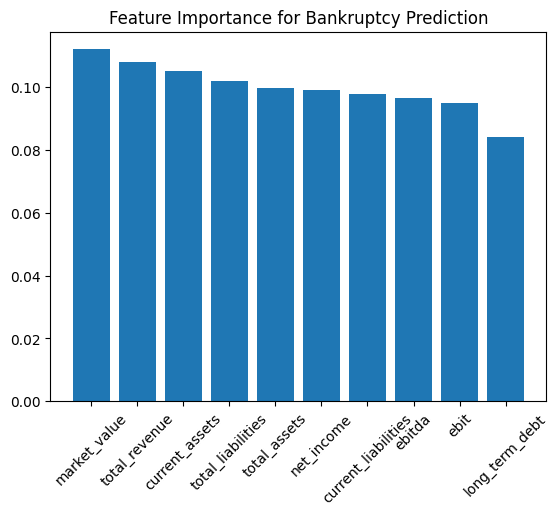

In [22]:
# make chart
import matplotlib.pyplot as plt

# visualize feature importance to compare the relative impact of each variable
# higher importance means the variable plays a larger role in the model’s decision-making
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance for Bankruptcy Prediction")
plt.show()

The feature importance results show that no single variable dominates bankruptcy prediction. Instead, multiple factors such as market value, total revenue, and liabilities all contribute similarly. This suggests that bankruptcy is driven by a combination of firm size, financial performance, and debt structure rather than a single indicator.

In [23]:
# compare pre and post 2008 to see if bankruptcy drivers change across economic periods
df_pre = df[df["year"] < 2008]
df_post = df[df["year"] >= 2008]

# pre 2008
X_pre = df_pre[features]
y_pre = df_pre["status_label"]

model_pre = RandomForestClassifier()
model_pre.fit(X_pre, y_pre)

# store feature importance for pre-2008
pre_df = pd.DataFrame({
    "feature": features,
    "importance_pre": model_pre.feature_importances_
})

# post 2008
X_post = df_post[features]
y_post = df_post["status_label"]

model_post = RandomForestClassifier()
model_post.fit(X_post, y_post)

# store feature importance for post-2008
post_df = pd.DataFrame({
    "feature": features,
    "importance_post": model_post.feature_importances_
})


               feature  importance_pre  importance_post
0       current_assets        0.105874         0.099531
1               ebitda        0.094810         0.094615
2           net_income        0.096378         0.104544
3         market_value        0.106965         0.130383
4         total_assets        0.102641         0.098773
5       long_term_debt        0.088550         0.081977
6                 ebit        0.091729         0.094284
7  current_liabilities        0.099640         0.092192
8        total_revenue        0.112942         0.103042
9    total_liabilities        0.100471         0.100661


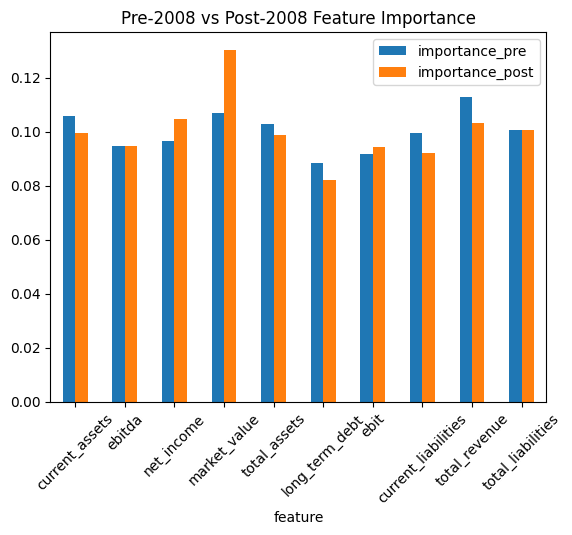

In [26]:
# merge results to directly compare how importance changes over time
comparison = pd.merge(pre_df, post_df, on="feature")
print(comparison)

# visualize differences between periods
comparison.plot(x="feature", y=["importance_pre", "importance_post"], kind="bar")
plt.xticks(rotation=45)
plt.title("Pre-2008 vs Post-2008 Feature Importance")
plt.show()

Comparing pre- and post-2008 results (pre-financial crisis vs post-financial crisis) shows small but noticeable changes. Market value and net income grow to be slightly more important after 2008, while long-term debt ends up being slightly less important. This is interesting becasue it suggests that after the financial crisis, bankruptcy risk may have been more tied to firm performance and market perception than just debt levels.

Overall, this analysis shows that companies go bankrupt due to multiple financial factors rather than one dominant variable. The 2008 financial crisis, a global economic collapse triggered by the housing market crash and failures of major financial institutions, serves as a natural breakpoint for changes in bankruptcy risk. While the relative importance of financial variables is fairly stable, there are small shifts after 2008 that suggest broader economic conditions can influence which factors matter most. This highlights that bankruptcy risk is not only firm-specific but also shaped by the economic environment.